In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = {
    "customer_id": [1, 2, 3, 4, 5],
    "age": [25, 34, 45, 22, 51],
    "monthly_charge": [29.99, 49.99, 79.99, 19.99, 99.99],
    "tenure_months": [12, 36, 5, 24, 60],
    "churned": [0, 0, 1, 0, 1]
}

df = pd.DataFrame(data)
print(df)
print("\nshape:", df.shape)
print("\ncolumn names:", df.columns.tolist())
print("\ndata types:\n", df.dtypes)

   customer_id  age  monthly_charge  tenure_months  churned
0            1   25           29.99             12        0
1            2   34           49.99             36        0
2            3   45           79.99              5        1
3            4   22           19.99             24        0
4            5   51           99.99             60        1

shape: (5, 5)

column names: ['customer_id', 'age', 'monthly_charge', 'tenure_months', 'churned']

data types:
 customer_id         int64
age                 int64
monthly_charge    float64
tenure_months       int64
churned             int64
dtype: object


In [4]:
print(df.head())
print("\n--- info ---")
df.info()
print("\n--- describe ---")
print(df.describe())

print("\n--- filter: customers who churned ---")
print(df[df["churned"] == 1])

print("\n--- filter: age > 30 AND high charge ---")
print(df[(df["age"] > 30) & (df["monthly_charge"] > 50)])

   customer_id  age  monthly_charge  tenure_months  churned
0            1   25           29.99             12        0
1            2   34           49.99             36        0
2            3   45           79.99              5        1
3            4   22           19.99             24        0
4            5   51           99.99             60        1

--- info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     5 non-null      int64  
 1   age             5 non-null      int64  
 2   monthly_charge  5 non-null      float64
 3   tenure_months   5 non-null      int64  
 4   churned         5 non-null      int64  
dtypes: float64(1), int64(4)
memory usage: 332.0 bytes

--- describe ---
       customer_id     age  monthly_charge  tenure_months   churned
count     5.000000   5.000        5.000000       5.000000  5.000000
me

In [3]:
data = {
    "customer_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "plan": ["basic", "basic", "premium", "premium", "basic", "premium", "basic", "premium"],
    "monthly_charge": [29.99, 29.99, 79.99, 89.99, 34.99, 79.99, 29.99, 99.99],
    "churned": [0, 1, 0, 0, 1, 1, 0, 0]
}
df = pd.DataFrame(data)

print(df)

print("\n--- avg charge per plan ---")
print(df.groupby("plan")["monthly_charge"].mean())

print("\n--- churn rate per plan ---")
print(df.groupby("plan")["churned"].mean())

print("\n--- multiple aggregations ---")
print(df.groupby("plan").agg(
    avg_charge=("monthly_charge", "mean"),
    customer_count=("customer_id", "count"),
    churn_rate=("churned", "mean")
))

   customer_id     plan  monthly_charge  churned
0            1    basic           29.99        0
1            2    basic           29.99        1
2            3  premium           79.99        0
3            4  premium           89.99        0
4            5    basic           34.99        1
5            6  premium           79.99        1
6            7    basic           29.99        0
7            8  premium           99.99        0

--- avg charge per plan ---
plan
basic      31.24
premium    87.49
Name: monthly_charge, dtype: float64

--- churn rate per plan ---
plan
basic      0.50
premium    0.25
Name: churned, dtype: float64

--- multiple aggregations ---
         avg_charge  customer_count  churn_rate
plan                                           
basic         31.24               4        0.50
premium       87.49               4        0.25


In [4]:
customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4, 5],
    "age": [25, 34, 45, 22, 51],
    "plan": ["basic", "premium", "basic", "premium", "basic"]
})

support_tickets = pd.DataFrame({
    "customer_id": [1, 1, 3, 5, 5, 5],
    "ticket_type": ["billing", "technical", "billing", "technical", "technical", "billing"]
})

print("customers:\n", customers)
print("\nsupport_tickets:\n", support_tickets)

ticket_counts = support_tickets.groupby("customer_id").size().reset_index(name="ticket_count")
print("\nticket_counts:\n", ticket_counts)

merged = customers.merge(ticket_counts, on="customer_id", how="left")
print("\nmerged:\n", merged)

merged["ticket_count"] = merged["ticket_count"].fillna(0)
print("\nfinal (no NaN):\n", merged)

customers:
    customer_id  age     plan
0            1   25    basic
1            2   34  premium
2            3   45    basic
3            4   22  premium
4            5   51    basic

support_tickets:
    customer_id ticket_type
0            1     billing
1            1   technical
2            3     billing
3            5   technical
4            5   technical
5            5     billing

ticket_counts:
    customer_id  ticket_count
0            1             2
1            3             1
2            5             3

merged:
    customer_id  age     plan  ticket_count
0            1   25    basic           2.0
1            2   34  premium           NaN
2            3   45    basic           1.0
3            4   22  premium           NaN
4            5   51    basic           3.0

final (no NaN):
    customer_id  age     plan  ticket_count
0            1   25    basic           2.0
1            2   34  premium           0.0
2            3   45    basic           1.0
3            4 

In [9]:
temps = np.array([72, 68, 95, 101, 88, 60, 77])
print(temps)
mask = (temps < 65) | (temps > 95)
print(mask)
extreme_temps = temps[mask]
print(extreme_temps)

[ 72  68  95 101  88  60  77]
[False False False  True False  True False]
[101  60]


In [15]:
df_filtered = df(df["age"] > 30 & df["monthly_charge"] > 50)

KeyError: 'age'

KeyError: 'age'

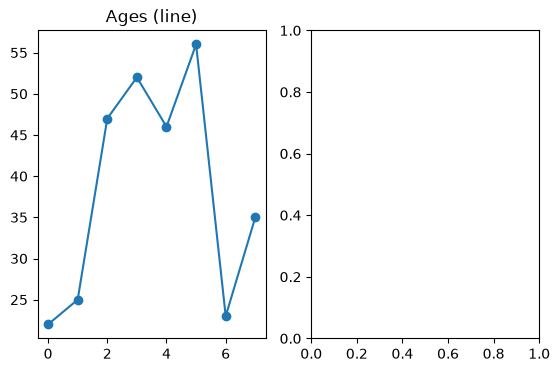

In [16]:
plt.figure(figsize=(10, 4))

# Plot 1: simple line plot
plt.subplot(1, 3, 1)
ages = [22, 25, 47, 52, 46, 56, 23, 35]
plt.plot(ages, marker='o')
plt.title("Ages (line)")

# Plot 2: histogram - distribution of a column
plt.subplot(1, 3, 2)
plt.hist(df["age"], bins=5, color='steelblue', edgecolor='black')
plt.title("Age distribution")
plt.xlabel("Age")

# Plot 3: scatter - relationship between two variables
plt.subplot(1, 3, 3)
colors = ['red' if c == 1 else 'green' for c in df["churned"]]
plt.scatter(df["age"], df["monthly_charge"], c=colors)
plt.title("Age vs Charge (red=churned)")
plt.xlabel("Age")
plt.ylabel("Monthly Charge")

plt.tight_layout()
plt.show()